<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/K_Mean_Live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#K-Mean



In [1]:
from google.colab import files
uploaded = files.upload()

Saving Live_20210128.csv to Live_20210128.csv


#Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Data Load

In [3]:
data = pd.read_csv("Live_20210128.csv")
data.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


# Data Exploration

In [4]:
data.shape

(7050, 16)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

In [6]:
data.isnull().sum()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


In [7]:
data =data.drop(["Column1","Column2","Column3","Column4"],axis = 1)

In [8]:
data.columns

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys'],
      dtype='object')

In [9]:
data = data.drop(["status_id"],axis = 1)

In [10]:
data.head()

,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


In [11]:
data.isnull().sum()

,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0
num_sads,0


In [12]:
data.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [13]:
data["status_type"].value_counts()

,count
status_type,
photo,4288
video,2334
status,365
link,63


In [14]:
data["status_published"].value_counts()

,count
status_published,
3/20/2018 1:54,3
5/25/2018 6:54,2
5/20/2018 6:18,2
5/17/2018 20:00,2
5/12/2018 1:57,2
...,...
9/7/2012 0:21,1
9/7/2012 4:32,1
9/7/2012 7:35,1


How many likes have been given to the photo posted on 4/19/2018 at 22:26?

In [15]:
pub = data[(data["status_type"] == "photo") & (data["status_published"] == "4/19/2018 22:26" )]["num_reactions"].values[0]
pub

np.int64(383)

How many total shares were made for the video post that was posted on 7/15/2017 at 10:52?

In [16]:
shares = data[(data["status_type"] == "video")&(data["status_published"]== "7/15/2017 10:52" )]["num_shares"].values[0]
shares

np.int64(167)

#Encode Categorical column

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["status_type"] = le.fit_transform(data["status_type"])

#outliers

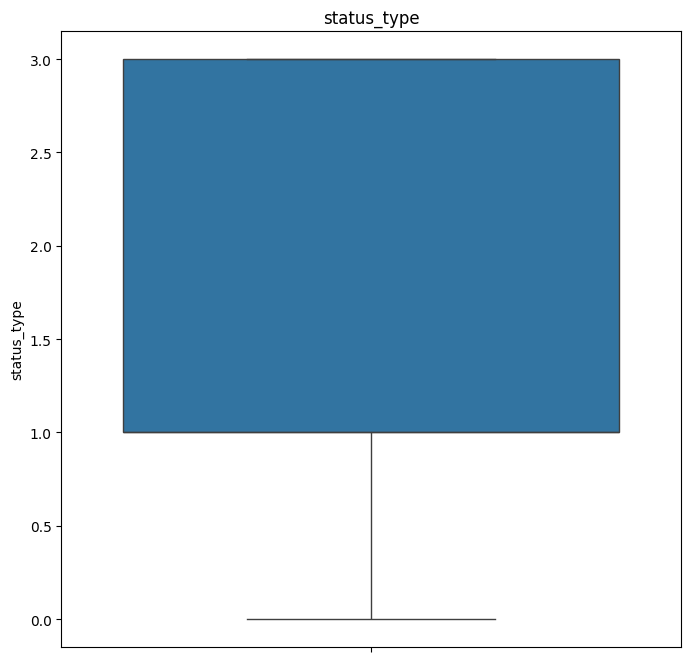

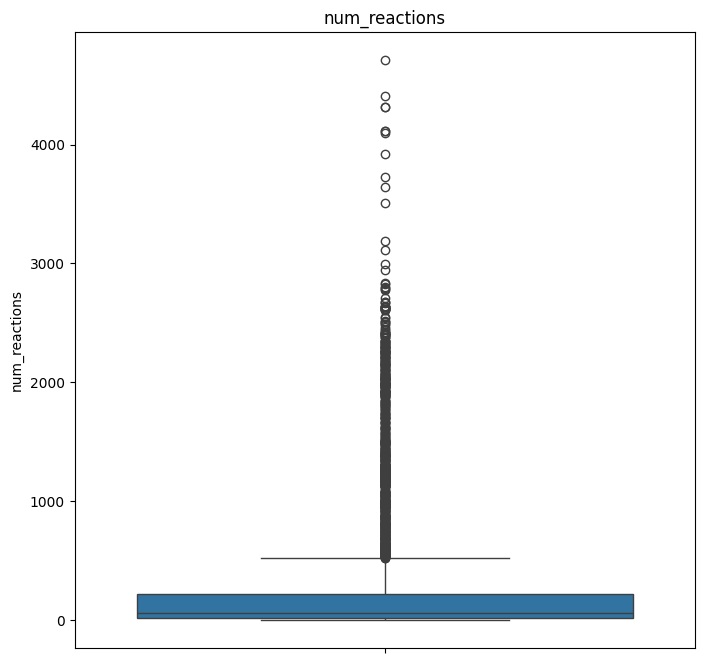

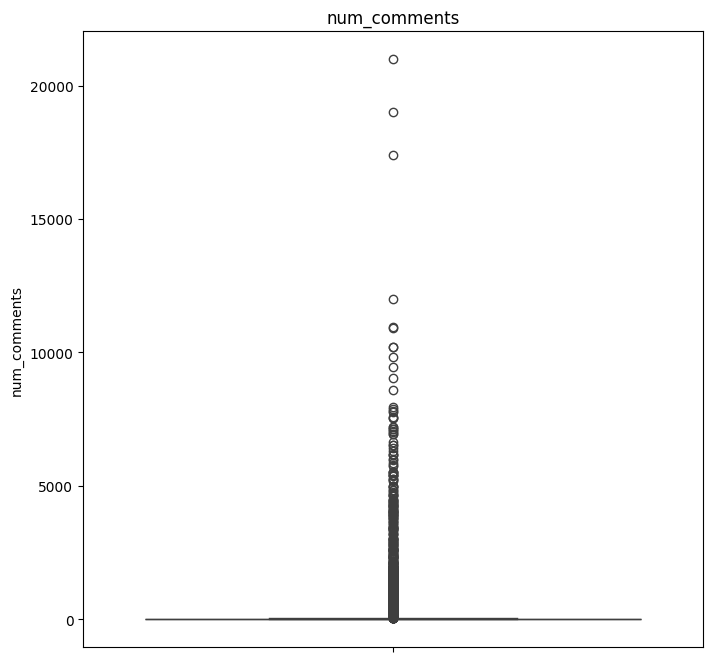

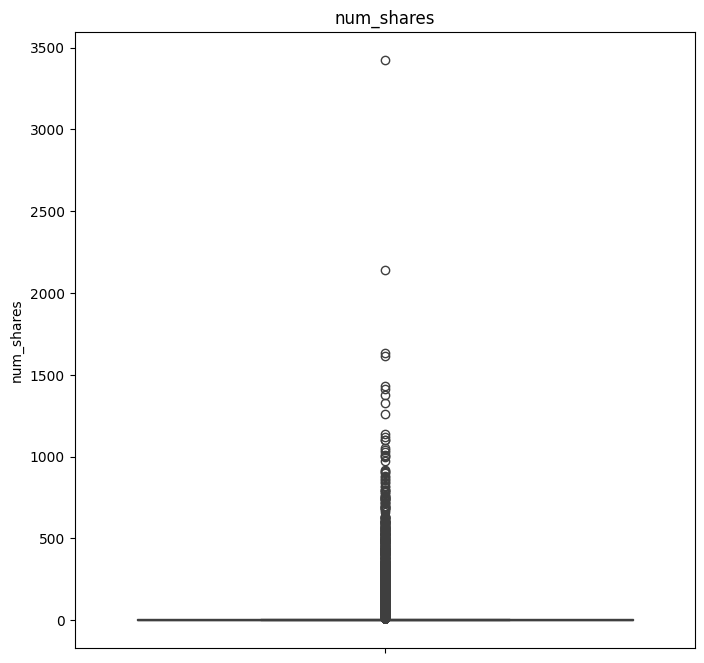

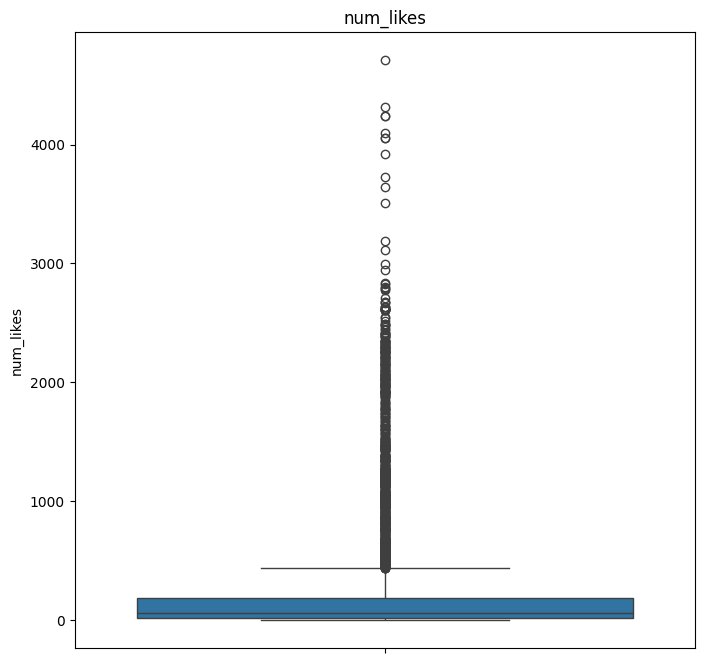

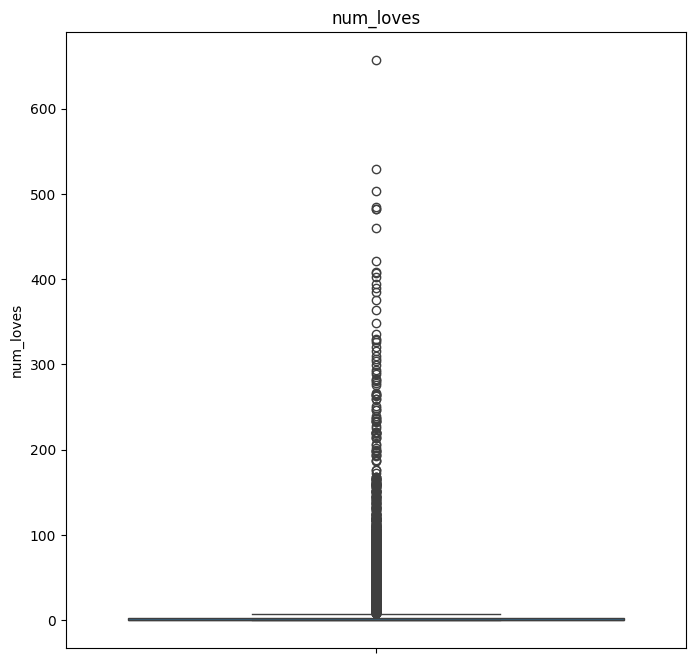

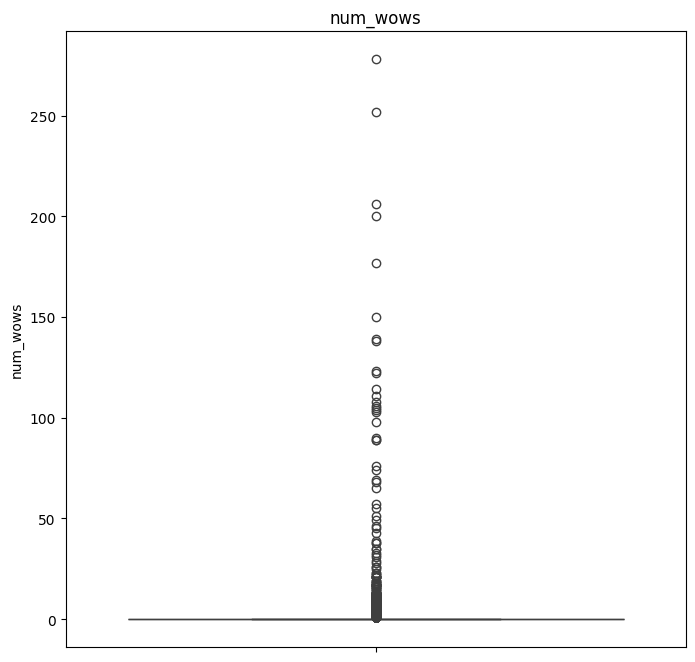

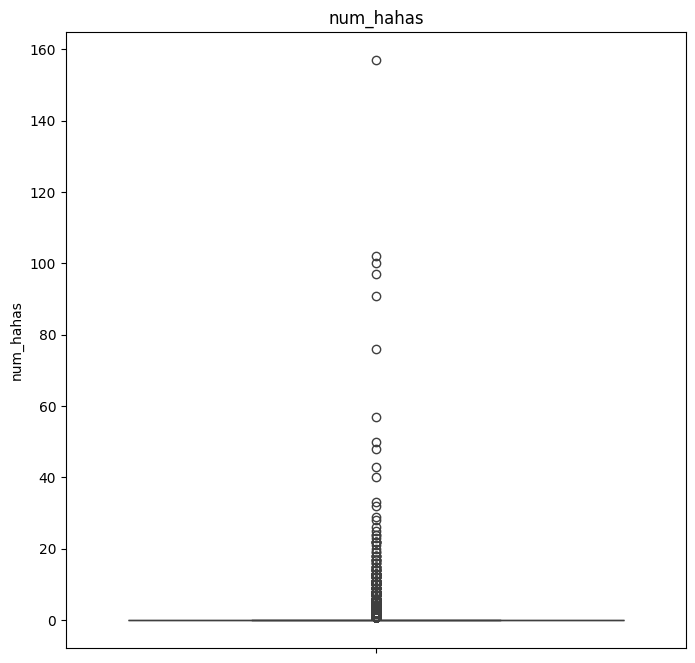

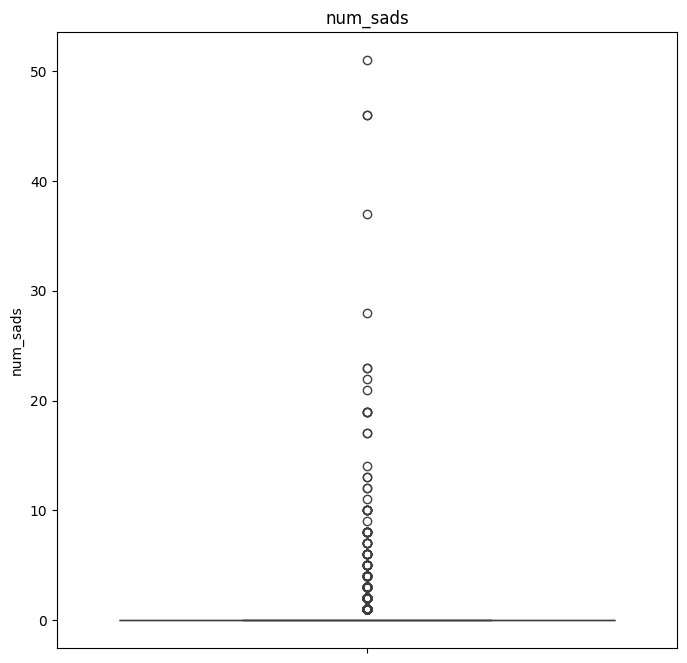

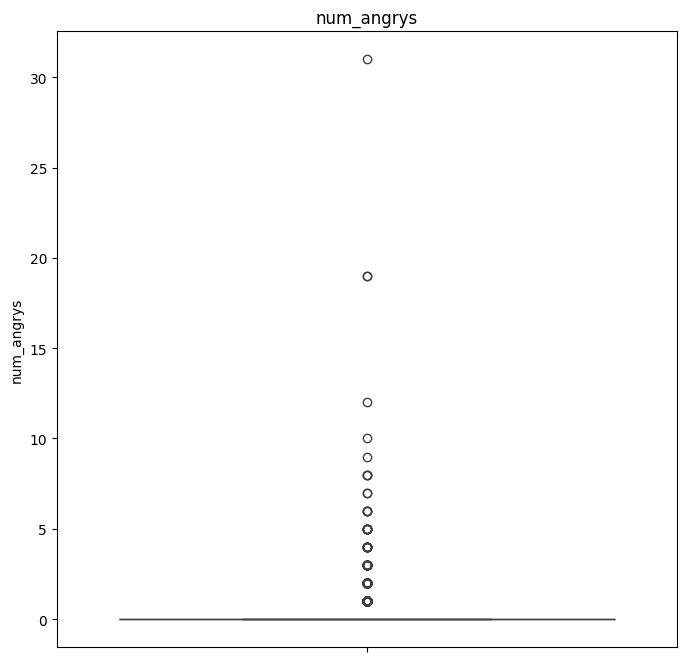

In [18]:
for col in data.columns:
  if((data[col].dtype == "int64") or (data[col].dtype == "float64")):
    plt.figure(figsize = (8,8))
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

#outlier removal

In [20]:
def remove_outliers(data):

    numeric_cols = data.select_dtypes(include=np.number)

    Q1 = numeric_cols.quantile(0.25)
    Q3 = numeric_cols.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[~((numeric_cols < lower) | (numeric_cols > upper)).any(axis=1)]

    return data

df_clean = remove_outliers(data)

print("Shape after outlier removal:", df_clean.shape)

Shape after outlier removal: (4123, 11)


In [23]:
df_clean = df_clean.drop(["status_published"],axis = 1)

In [24]:
df_clean.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
1,1,150,0,0,150,0,0,0,0,0
3,1,111,0,0,111,0,0,0,0,0
8,1,203,1,0,198,5,0,0,0,0
9,1,170,9,1,167,3,0,0,0,0
19,1,152,2,0,149,3,0,0,0,0


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)

In [26]:
data_scaled

array([[-0.55284393,  1.40357969, -0.55599357, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55284393,  0.86592605, -0.55599357, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55284393,  2.13423719, -0.4061856 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.55284393,  0.56263426, -0.55599357, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55284393, -0.63674692, -0.55599357, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55284393, -0.42995706, -0.55599357, ...,  0.        ,
         0.        ,  0.        ]])

#Implementing K-Mean

In [27]:
from sklearn.cluster import KMeans

#Elbow-Method

In [28]:
# Elbow curve method to find ideal number of clusters
wcss = []


for i in range(1,11):
  kmeans = KMeans(n_clusters =i,random_state = 42)
  kmeans.fit(data_scaled)
  wcss.append(kmeans.inertia_)




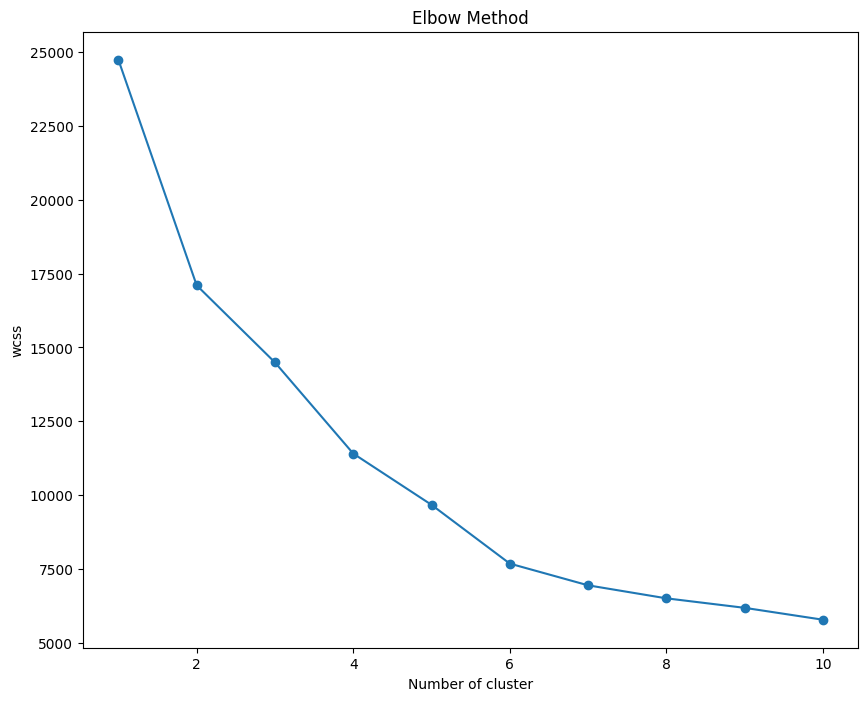

In [29]:
plt.figure(figsize = (10,8))
plt.plot(range(1,11),wcss,marker = "o")
plt.xlabel("Number of cluster")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

#Silhouette Score(Cluster Quality)

In [30]:
from sklearn.metrics import silhouette_score
for k in range(2,10):
  kmeans = KMeans(n_clusters =k,random_state = 42)
  label = kmeans.fit_predict(data_scaled)
  score = silhouette_score(data_scaled,label)
  print("clusters:",k,"silhouette score:",score)

clusters: 2 silhouette score: 0.58822378792184
clusters: 3 silhouette score: 0.5677599765255235
clusters: 4 silhouette score: 0.48442461445427615
clusters: 5 silhouette score: 0.5061205029812667
clusters: 6 silhouette score: 0.5165635653705124
clusters: 7 silhouette score: 0.48094996767806164
clusters: 8 silhouette score: 0.5122440232917288
clusters: 9 silhouette score: 0.4667354980528849


In [31]:
kmeans = KMeans(n_clusters = 2,random_state = 42)
clusters = kmeans.fit_predict(data_scaled)
df_clean["cluster"] = clusters

In [32]:
df_clean["cluster"].value_counts()

,count
cluster,
0,3629
1,494


In [34]:
df_clean.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
1,1,150,0,0,150,0,0,0,0,0,0
3,1,111,0,0,111,0,0,0,0,0,0
8,1,203,1,0,198,5,0,0,0,0,1
9,1,170,9,1,167,3,0,0,0,0,1
19,1,152,2,0,149,3,0,0,0,0,1


#1st Cluster

In [37]:
df_clean[df_clean["cluster"] == 0].sort_values(by= ['status_type', 'num_reactions', 'num_comments'],ascending = [False,False,False]).head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
1609,3,154,0,0,154,0,0,0,0,0,0
1669,3,141,1,1,141,0,0,0,0,0,0
1728,3,137,3,1,137,0,0,0,0,0,0
1652,3,135,1,2,135,0,0,0,0,0,0
1637,3,131,1,1,131,0,0,0,0,0,0


#2nd cluster

In [38]:
df_clean[df_clean["cluster"] == 1].sort_values(by = ['status_type','num_reactions','num_comments'],ascending = [False,False,False])

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
1354,3,435,9,1,435,0,0,0,0,0,1
1373,3,433,7,0,433,0,0,0,0,0,1
1409,3,433,4,0,433,0,0,0,0,0,1
1369,3,432,5,0,432,0,0,0,0,0,1
1457,3,426,9,2,426,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
2208,1,34,44,0,34,0,0,0,0,0,1
2536,1,33,47,0,33,0,0,0,0,0,1
4480,1,16,50,0,16,0,0,0,0,0,1
4715,0,120,26,0,120,0,0,0,0,0,1


#PCA Visualisation

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
x_pca = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(x_pca,columns = ["pca1","pca2"])
pca_df["cluster"] = clusters

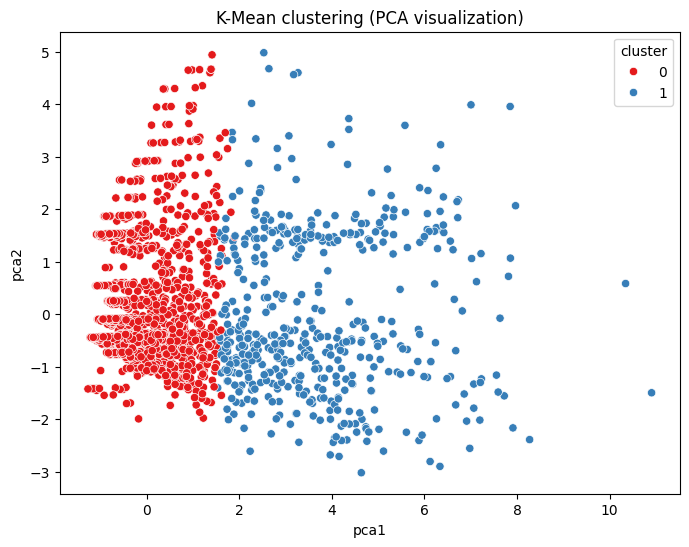

In [40]:
plt.figure(figsize = (8,6))

sns.scatterplot(data=pca_df,x = "pca1",y = "pca2",hue = "cluster",palette = "Set1")
plt.title("K-Mean clustering (PCA visualization)")
plt.show()